# Prior-Data Fitted Networks
Prior-Data Fitted Networks (PFNs, Müller et al., 2021) are models trained on synthetic data generated from specified priors to directly capture the influence of prior knowledge. Unlike standard deep learning, which incorporates priors indirectly through regularization (e.g., weight decay or data augmentation), PFNs aim to approximate the **posterior predictive distribution** (PPD) of model parameters given a dataset $\mathcal{D}$, as follows:

$$
P(y \mid x, \mathcal{D}) = \int P(y \mid x, \theta) P(\theta \mid \mathcal{D}) \, d\theta, \quad 
P(\theta \mid \mathcal{D}) \propto P(\mathcal{D} \mid \theta) P(\theta)
$$

PFNs employ large-scale machine learning techniques to approximate the PPD, enabling predictions about the distribution of $y$ for a new data point $x$, given a dataset $\mathcal{D}$.

> "The primary requirement for PFNs is the capability to sample from a prior distribution over supervised learning tasks. PFNs are essentially learning to approximate Bayesian inference."  
> — Müller et al., 2021



## Applications

Prior data proves most valuable in contexts where large datasets are not available. While abundant data can inherently define its own priors, understanding priors becomes crucial with smaller, high-quality datasets. Bayesian inference, facilitated by PFNs, excels in these scenarios by leveraging prior knowledge.

PFNs are particularly suited for machine learning tasks involving small, high-quality datasets, often dealing with datasets of up to 1000 points.

## Content

In this tutorial, following the work of Müller et al. (2021) and Hollmann et al. (2023), we will explore how neural networks can approximate PPD for various priors. We will cover:

1. Defining a prior for ridge regression.
2. Creating a dataset loader for endless synthetic data generation from the prior.
3. Developing a transformer model to approximate PPD.
4. Formulating a loss function specific to regression.
5. Evaluating the output quality.

### Note

This tutorial has been created based on my interpretation of the paper and the GitHub repositories linked in the respective papers.


References:
- [Müller et al. (2021)](https://arxiv.org/abs/2112.10510) "Transformers Can Do Bayesian Inference."
- [Hollmann et al. (2023)](https://arxiv.org/abs/2207.01848) "TabPFN: A Transformer That Solves Small Tabular Classification Problems in a Second."


In [1]:
# basic imports
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn.modules.transformer import MultiheadAttention

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", device)
else:
    device = torch.device("cpu")
    print("No GPU -> using CPU:", device)

No GPU -> using CPU: cpu


## Data Generating Prior

For a Prior-Data Fitted Network (PFN), it's crucial to generate synthetic data based on well-defined priors. In this tutorial, we'll explore a PFN designed to approximate the Posterior Predictive Distribution (PPD), where the model parameters $\theta$ are drawn from a normal distribution centered around the origin.

---

### Bayesian Linear Regression Model
We start with the simplest prior. We want to predict PPD for normally distributed outcomes. Each dataset has $X$ (n × p features) and $y$ (n targets) with unknown $\beta$ (p coefficients).

We model the output (likelihood) as:

$$
y = X \beta + \epsilon, \quad \epsilon \sim N(0, \sigma^2 I)
$$

Where  $\sigma^2$ is the likelihood variance (noise in y). The coefficients $\beta$ are sampled from a normal distribution (Gaussian / Ridge-like):  

$$
\beta \sim N(0, \tau^2 I)
$$

Where $\tau^2$ is the prior variance.

Refrereces:

https://en.wikipedia.org/wiki/Bayesian_linear_regression

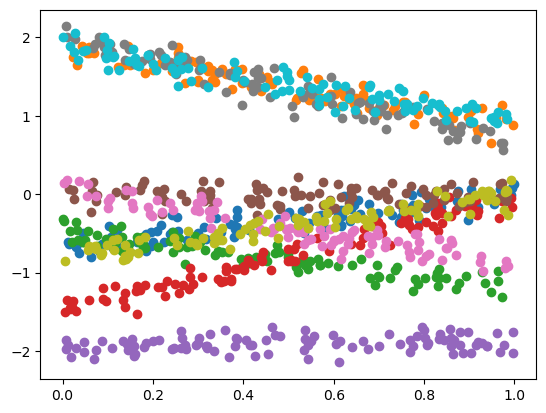

In [11]:
num_datasets = 10
num_points_in_each_dataset = 100
hyperparameters = {
    'prior_variance': 1.0,
    'y_noise': 0.1,
}
num_features = 1

def generate_bayesian_linear_regression_prior(num_datasets, num_features, num_points_in_each_dataset, hyperparameters):
    """
    Args:
        num_datasets: number of datasets in each batch
        num_features: number of features to use
        num_points_in_each_dataset: number of points in each dataset
        hyperparameters: hyperparameters to define the prior
        
    Returns:
        x, y
    """

    # Sample weights for ridge regression
    beta_s = torch.distributions.Normal(torch.zeros(num_features + 1), hyperparameters['prior_variance']).sample((num_datasets,)) # a tensor of shape (num_datasets, 1)
    
    Xs = torch.rand(num_datasets, num_points_in_each_dataset, num_features)
    Xs_ = torch.cat([Xs, torch.ones(num_datasets, num_points_in_each_dataset, 1)], 2)
    
    ys = torch.distributions.Normal(torch.einsum('nmf, nf -> nm', Xs_, beta_s), hyperparameters['y_noise']).sample()

    return Xs, ys

Xs, ys = generate_bayesian_linear_regression_prior(num_datasets, num_features, num_points_in_each_dataset, hyperparameters)
for dataset_index in range(num_datasets):
    plt.scatter(Xs[dataset_index,:,0].numpy(), ys[dataset_index].numpy())

## Distributional Regression
PFNs aim to approximate the \textit{posterior predictive distribution} (PPD). 
This corresponds to \textit{distributional regression}, which models the entire 
conditional distribution $p(y \mid x)$ rather than only the conditional mean. Instead of predicting just $\mu(x) = \mathbb{E}[y \mid x]$. It estimates all relevant distributional parameters (e.g., mean, variance, skewness, tail behavior), providing uncertainty quantification 
and flexibility for heteroskedastic or skewed data.


To approximate the full conditional distribution  $p(y \mid x)$ of a continuous target, we discretize the support of $y$ into intervals ("buckets" or bins). This reduces distributional regression to predicting a categorical distribution over buckets. The model then predicts a **probability mass function** over those buckets instead of a density directly.


The following steps outline this process:

1. `get_bucket_limits`: Create buckets for y-values such that each bucket contains an approximately equal number of observations (y's). This process will result in narrower buckets in regions where y-values are densely packed.
2. `y_to_bucket_idx`: Assing the y-values to their respective buckets.


In [47]:
_, ys = generate_bayesian_linear_regression_prior(100000, num_features, 100, hyperparameters)



def get_bucket_limits(num_outputs, ys):
    """
    Create bucket borders for y by sorting and splitting into equal parts.
    """
    ys = ys.flatten()
    n = len(ys) - len(ys) % num_outputs
    ys_sorted, _ = ys[:n].sort()
    step = n // num_outputs

    mids = (ys_sorted[step-1::step][:-1] + ys_sorted[step::step]) / 2
    return torch.cat([ys_sorted[:1], mids, ys_sorted[-1:]])


num_outputs = 100
bucket_limits = get_bucket_limits(num_outputs, ys)

In [50]:
def y_to_bucket_idx(ys, bucket_limits):
    """
    Maps the value of y to the corresponding bucket in `bucket_limits`
    """
    target_sample = torch.searchsorted(bucket_limits, ys) - 1
    target_sample[ys <= bucket_limits[0]] = 0
    target_sample[ys >= bucket_limits[-1]] = len(bucket_limits) - 1 - 1
    return target_sample

target = y_to_bucket_idx(ys, bucket_limits)

## Transformer model

Here, we use Transfomer architecture as our PFN model. The model predicts probability mass function.

In [52]:
class Encoder(nn.Module):
    """Typical self attention module in transformer"""
    def __init__(self, d_model, n_heads, n_hidden, dropout=0.1):
        super().__init__()
        self.self_attn = MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.out = nn.Sequential(
            nn.Linear(d_model, n_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(n_hidden, d_model),
        )
        
        self.dropout = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
    def forward(self, src, trainset_size):
        src_left, src_right = src[:, :trainset_size], src[:, trainset_size:]
        x_left = self.self_attn(src_left, src_left, src_left)[0] # all train points to each other
        x_right = self.self_attn(src_right, src_left, src_left)[0] # test points attend to train points
        x = torch.cat([x_left, x_right], dim=1)
        x = self.norm1(src + self.dropout(x))
        return self.norm2(self.dropout(self.out(x)) + x)


class Transformer(nn.Module):
    def __init__(self, num_features, n_out, n_layers=2, d_model=512, n_heads=4, n_hidden=1024, dropout=0.0, normalize=lambda x:x):
        super().__init__()
        
        self.x_encoder = nn.Linear(num_features, d_model)
        self.y_encoder = nn.Linear(1, d_model)
        
        self.model = nn.ModuleList(
            [Encoder(d_model, n_heads, n_hidden, dropout) for _ in range(n_layers)]
        )
        
        self.out = nn.Sequential(
            nn.Linear(d_model, n_hidden),
            nn.GELU(),
            nn.Linear(n_hidden, n_out)
        )
                
        self.normalize = normalize
        self.init_weights()
        
    def forward(self, x, y, trainset_size):
        """
        Args:
            x: num_datasets x number_of_points x num_features
            y: num_datasets x number_of_points
            trainset_size: int specifying the number of points to use as training dataset size
        
        Returns:
            outputs for each x
        """
        x_src = self.x_encoder(self.normalize(x))
        y_src = self.y_encoder(y)
        
        src = torch.cat([x_src[:, :trainset_size] + y_src[:, :trainset_size], x_src[:, trainset_size:]], dim=1)
        for encoder in self.model:
            src = encoder(src, trainset_size)

        return self.out(src)
    
    def init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

## Dataloader

To train a PFN, we will need a dataloader that can continuously generate the synthetic dataset.

An important consideration in the data generation process is the size of each training set, denoted as `trainset_size`. In the context of PFNs, it's beneficial to expose the network to larger datasets, as they typically contain more information and offer a better approximation of the true data distribution. To ensure that our PFN frequently encounters larger datasets, we'll implement a function named `_sample_trainset_size`.

In [53]:
class PriorDataLoader(object):
    def __init__(self, get_prior_data_fn, batch_size, num_points_in_each_dataset, seed=0):
        self.batch_size = batch_size
        self.num_points_in_each_dataset = num_points_in_each_dataset
        self.get_prior_data_fn = get_prior_data_fn
        self.epoch = 0
        self.rng = np.random.default_rng(seed)  

        min_samples = 1
        max_samples = self.num_points_in_each_dataset - 1
        self._trainset_sizes = np.arange(min_samples, max_samples)
        self._trainset_weights = 1 / (max_samples - min_samples - np.arange(max_samples - min_samples))
        self._trainset_weights /= self._trainset_weights.sum()  # normalize

    def get_batch(self, train = True, batch_size=None):
        """
        Returns:
            xs, ys, trainset_size
        """
        self.epoch += train
        bs = batch_size if batch_size else self.batch_size
        return self.get_prior_data_fn(bs, self.num_points_in_each_dataset), self._sample_trainset_size()

    def _sample_trainset_size(self):
        # weighted sampling using NumPy RNG
        return self.rng.choice(self._trainset_sizes, p=self._trainset_weights)

In [76]:
model = Transformer(1, 100, n_layers=3, d_model=256, n_heads=2, n_hidden=128, dropout=0.0 )
get_prior_data_fn = lambda x, y: generate_bayesian_linear_regression_prior(x, num_features, y, hyperparameters)
dl = PriorDataLoader(get_prior_data_fn, 1, 4)

(xs, ys), trainset_size = dl.get_batch(False)
pred_y = model(xs, ys.unsqueeze(-1), trainset_size)

## Loss function

The authors model continuous distributions using discretized continuous distributions, which they refer to as the 'Riemann Distribution.' The Probability Density Functions (PDFs) of this distribution resemble bar plots. The boundaries are chosen so that each bucket has the same probability in the prior data, denoted as $p(y \in b) = 1/{\mathbf{B}}$, where $\mathbf{B}$ represents the number of buckets. This approach, of course, assumes a bounded support; therefore, the authors modify it by adjoining half-normals towards each end.

<img src='images/bar-dist.png' width=500px>

Thus, if $b$ is the bucket such that it has the width denoted by $\text{width}_b$, probability of $P(Y=y \mid y \in b) = 1/\text{width}_b$

$$
P(Y = y) = P(y \in b) \times P(Y = y| y \in b)
$$

$$
P(Y = y) =  1 / \text{width}_b \times P(y \in b)
$$



In [77]:
def get_halfnormal_with_p_weight_before(range_max, p=0.5):
    """Half-normal scaled so that `p` portion lies within range_max."""
    s = range_max / torch.distributions.HalfNormal(1.).icdf(torch.tensor(p))
    return torch.distributions.HalfNormal(s)

def compute_bar_distribution_loss(logits, target_y, bucket_limits):
    """Reimann distribution loss with half-normal edge corrections."""
    target_idx = y_to_bucket_idx(target_y, bucket_limits)
    widths = bucket_limits[1:] - bucket_limits[:-1]
    log_probs = torch.log_softmax(logits, -1) - torch.log(widths)
    log_probs = log_probs.gather(-1, target_idx[..., None]).squeeze(-1)

    # Half-normal edge corrections
    left, right = get_halfnormal_with_p_weight_before(widths[0]), get_halfnormal_with_p_weight_before(widths[-1])
    first, last = target_idx == 0, target_idx == len(widths)-1
    
    if first.any():
        log_probs[first] += (left.log_prob(bucket_limits[1]-target_y[first])
                             .clamp(min=1e-8) + torch.log(widths[0]))
    if last.any():
        log_probs[last] += (right.log_prob(target_y[last]-bucket_limits[-2])
                            .clamp(min=1e-8) + torch.log(widths[-1]))

    return -log_probs.mean()

In [78]:
logits = pred_y[:, trainset_size:]
target_y = ys[:, trainset_size:].clone().view(*logits.shape[:-1])

compute_bar_distribution_loss(logits.cpu(), target_y.cpu(), bl.cpu())

tensor(1.2213, grad_fn=<NegBackward0>)

## Train the transformer

Here we will use the standard setup required to train transformers.

#### Note
There are two important factors that impact the performance of the models: **input normalization** and **dropout**. Having a non-zero value for dropout can result in a PPD (Posterior Predictive Distribution) that is not smooth, while the absence of a normalization scheme may lead to poor performance due to inconsistency in the inputs.

In [79]:
from transformers import get_cosine_schedule_with_warmup


In [135]:
# Parameters related to prior data
num_points_in_each_dataset = 32
hyperparameters = {
    'prior_variance': 1.0,
    'y_noise': 0.1,
}
num_features = 1
num_outputs = 20
max_num_datasets = 128


# Reimannian distribution
_, ys = generate_bayesian_linear_regression_prior(100000, num_features, num_points_in_each_dataset, hyperparameters)
bucket_limits = get_bucket_limts(num_outputs, ys)

# training data
get_prior_data_fn = lambda x, y: generate_bayesian_linear_regression_prior(x, num_features, y, hyperparameters)
dl = PriorDataLoader(get_prior_data_fn, batch_size=max_num_datasets, num_points_in_each_dataset=num_points_in_each_dataset)

# Models
model = Transformer(num_features, n_out=num_outputs, d_model=16, n_layers=4, n_hidden=32, n_heads=4)

# Learning
epochs = 20
steps_per_epoch = 100
warmup_epochs = epochs // 4
validate_epoch = 5
lr = 0.001

model.to(device)
bucket_limits = bucket_limits.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_epochs, epochs)

# test data
(test_xs, test_ys), test_trainset_size = dl.get_batch(False, 64)
test_xs, test_ys = test_xs.to(device), test_ys.to(device)

for step in range(epochs * steps_per_epoch + 1):
    (xs, ys), trainset_size = dl.get_batch()
    xs, ys = xs.to(device), ys.to(device)
    pred_y = model(xs, ys.unsqueeze(-1), trainset_size)

    logits = pred_y[:, trainset_size:]
    target_y = ys[:, trainset_size:].clone().view(*logits.shape[:-1])
    
    loss = compute_bar_distribution_loss(logits, target_y, bucket_limits)
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)
    optimizer.step()
    scheduler.step()
    
    if step % (validate_epoch * steps_per_epoch) == 0:
        with torch.no_grad():
            pred_test_y = model(test_xs, test_ys.unsqueeze(-1), test_trainset_size)

            logits = pred_test_y[:, test_trainset_size:]
            target_test_y = test_ys[:, test_trainset_size:].clone().view(*logits.shape[:-1])

            val_loss = compute_bar_distribution_loss(logits, target_test_y, bucket_limits)

        print(f'@Step: {step}\tVal loss:{val_loss.item(): 0.5f}\t lr:{scheduler.get_last_lr()[0]: 0.6e}\t train_loss:{loss.item(): 0.5f}')

@Step: 0	Val loss: 1.63867	 lr: 2.000000e-04	 train_loss: 1.65465
@Step: 500	Val loss:-0.22122	 lr: 1.092620e-05	 train_loss:-0.18997
@Step: 1000	Val loss:-0.42302	 lr: 6.545085e-04	 train_loss:-0.49272
@Step: 1500	Val loss:-0.47846	 lr: 8.345653e-04	 train_loss:-0.53958
@Step: 2000	Val loss:-0.53491	 lr: 1.092620e-05	 train_loss:-0.45834


## Compute metrics and visualize

In [136]:
def compute_mean(logits, bucket_limits):
    """
    Computes mean from logits
    
    Args:
        logits: num_datasets  x num_points_in_each_dataset x num_outputs_for_classification
        bucket_limits: border limits for each class
    
    Returns:
        means
    """
    bucket_widths = bucket_limits[1:] - bucket_limits[:-1]
    bucket_means = bucket_limits[:-1] + bucket_widths / 2
    p = torch.softmax(logits, dim=-1)
    
    # full support correction through half normal (see Appendix E of Muller et al. 2021)
    side_normals = (
        get_halfnormal_with_p_weight_before(bucket_widths[0]),
        get_halfnormal_with_p_weight_before(bucket_widths[-1])
    )
    bucket_means[0] = -side_normals[0].mean + bucket_widths[1]
    bucket_means[-1] = side_normals[1].mean + bucket_widths[-2]
    
    return p @ bucket_means

def cdf(logits, left_prob, bucket_limits):
    """
    Computes quantile corresponding to left_prob
    
    Args:
        logits: num_datasets  x num_points_in_each_dataset x num_outputs_for_classification
        left_prob: probability of the output to be less than this value
        bucket_limits: border limits for each class
    
    Returns:
        points corresponding to left_prob
    
    """
    probs = torch.softmax(logits, -1)
    cumprobs = torch.cumsum(probs, -1)
    idx = torch.searchsorted(cumprobs, left_prob * torch.ones(*cumprobs.shape[:-1], 1)).squeeze(-1).clamp(0, cumprobs.shape[-1] - 1)
    cumprobs = torch.cat([torch.zeros(*cumprobs.shape[:-1], 1, device=logits.device), cumprobs], -1)
    
    rest_prob = left_prob - cumprobs.gather(-1, idx[..., None]).squeeze(-1)
    left_border = bucket_limits[idx]
    right_border = bucket_limits[idx+1]
    return left_border + (right_border - left_border) * rest_prob / probs.gather(-1, idx[..., None]).squeeze(-1)
    

def compute_quantile(logits, bucket_limits, center_prob = 0.682):
    """
    Computes +/- quantiles corresponding to cetner_prob.
    
    Args:
        logits: num_datasets  x num_points_in_each_dataset x num_outputs_for_classification
        bucket_limits: border limits for each class
        center_prob: Probability mass for the points to be in the middle of mean +/- quantile value
    
    Returns:
        left quantile, right quantile
    
    """
    # center_prob = 0.682 area under the normal function within 1 std
    side_prob = (1.0-center_prob)/2
    
    # compute the quantile corresp. to this side_prob and  1-side_prob
    return torch.stack([cdf(logits, side_prob, bucket_limits), cdf(logits, 1-side_prob, bucket_limits)], -1)
    

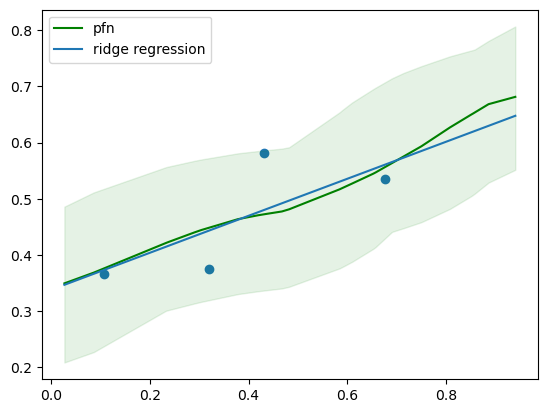

In [174]:
import sklearn

(xs, ys), num_training_points = dl.get_batch()

batch_index = 0
num_training_points = 4 # this is the trainset_size

xs_train = xs[batch_index, :num_training_points]
ys_train = ys[batch_index, :num_training_points]
xs_test = xs[batch_index, num_training_points:]

with torch.no_grad():
    logits = model(xs.to(device), ys.unsqueeze(-1).to(device), num_training_points)

# predicted means from a bar distribution
test_logits = logits[batch_index, num_training_points:].cpu()
pred_means = compute_mean(test_logits, bucket_limits.cpu())
pred_confs = compute_quantile(test_logits, bucket_limits.cpu())

# plot pfn
plt.scatter(xs_train[..., 0], ys_train)
order_test_x = xs_test[..., 0].argsort()
plt.plot(xs_test[order_test_x, 0], pred_means[order_test_x], color='green', label='pfn')
plt.fill_between(xs_test[order_test_x, 0], pred_confs[order_test_x, 0], pred_confs[order_test_x, 1], alpha=0.1, color='green')

ridge_model = sklearn.linear_model.Ridge(alpha=(hyperparameters['y_noise']/hyperparameters['prior_variance'])**2)
ridge_model.fit(xs_train, ys_train)
plt.plot(xs_test[order_test_x, 0], ridge_model.predict(xs_test[order_test_x]), label='ridge regression')
plt.legend()
# plt.plot();

### Visualizing Riemann distribution

<BarContainer object of 20 artists>

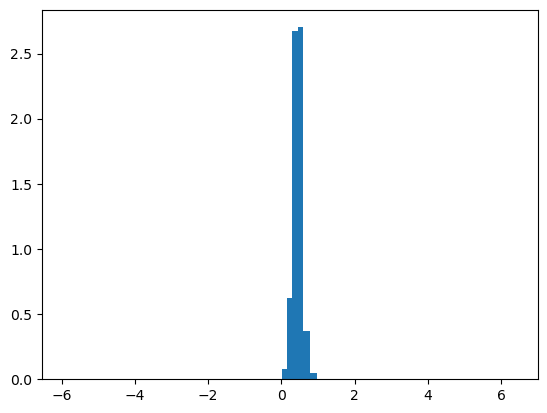

In [177]:
idx = 10
probs_of_first_pred = logits[batch_index, order_test_x[idx]].softmax(-1).detach().cpu().numpy()

borders = bucket_limits.cpu()
widths = borders[1:] - borders[:-1]

density_of_first_pred = probs_of_first_pred / widths

plt.bar(borders[:-1].tolist(), density_of_first_pred.tolist(), width=widths, align='edge')